# Practical 03: Logistic Regression

## Objective

company is planing to launch a campaign for their new car brand and would like to analyze which customer are most likely to purchse the car so that the ads can be design to specificly target that customer in order to achieve this they consent a social network achievement company that posses the data from another similar campaign. it is now desired to construct a model to acheive the goal. using lg reg. to predict if a customer is going a buy a new car or not.

In [53]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


## Load Dataset

In [54]:
purchase_data = pd.read_csv('Data.csv')
X = purchase_data.iloc[:, [2, 3]].values
y = purchase_data.iloc[:, 4].values

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)


Feature Matrix Shape: (400, 2)
Target Vector Shape: (400,)


## Train-Test Split

In [55]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=10
)


## Feature Scaling

In [56]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Logistic Regression Model

In [57]:

model = LogisticRegression(random_state=10)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",10
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## Predictions

In [58]:

y_pred = model.predict(X_test)


## Model Evaluation

In [59]:

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Model Accuracy: 0.8875

Confusion Matrix:
 [[48  4]
 [ 5 23]]


## Confusion Matrix Visualization

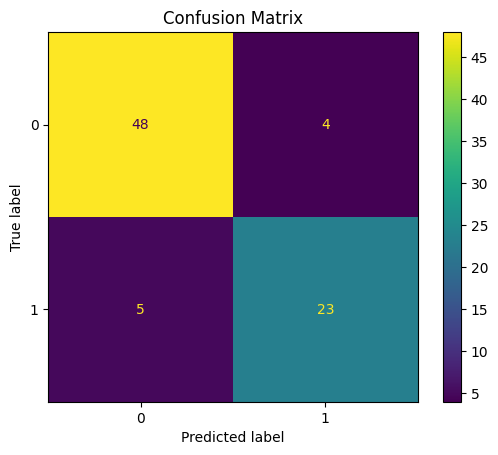

In [60]:

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


## Prediction Probabilities

In [61]:

y_prob = model.predict_proba(X_test)

print("First 5 Predictions:")
for i in range(5):
    print(f"Customer {i+1}:")
    print(f"  Probability of NOT buying: {y_prob[i][0]:.2f}")
    print(f"  Probability of BUYING: {y_prob[i][1]:.2f}")
    print(f"  Final Prediction: {y_pred[i]}")


First 5 Predictions:
Customer 1:
  Probability of NOT buying: 0.56
  Probability of BUYING: 0.44
  Final Prediction: 0
Customer 2:
  Probability of NOT buying: 0.75
  Probability of BUYING: 0.25
  Final Prediction: 0
Customer 3:
  Probability of NOT buying: 0.37
  Probability of BUYING: 0.63
  Final Prediction: 1
Customer 4:
  Probability of NOT buying: 0.44
  Probability of BUYING: 0.56
  Final Prediction: 1
Customer 5:
  Probability of NOT buying: 0.99
  Probability of BUYING: 0.01
  Final Prediction: 0


# Method 2: Logistic Regression Gradient Descent (Homework)

In [62]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

X_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]

theta = np.zeros(X_b.shape[1])
learning_rate = 0.1
iterations = 1000

for i in range(iterations):
    z = X_b.dot(theta)
    h = sigmoid(z)

    gradient = (X_b.T.dot(h - y_train)) / len(y_train)
    theta -= learning_rate * gradient

    if (i + 1) % 100 == 0:
        print(f"Iteration {i+1} - Theta: {theta}")


def predict(X, theta):
    X_b_pred = np.c_[np.ones((X.shape[0], 1)), X]
    probabilities = sigmoid(X_b_pred.dot(theta))
    return (probabilities >= 0.5).astype(int)

y_pred_gd = predict(X_test, theta)

accuracy_gd = accuracy_score(y_test, y_pred_gd)
print("Gradient Descent Accuracy:", accuracy_gd)

Iteration 100 - Theta: [-0.62561687  1.27263428  0.63597116]
Iteration 200 - Theta: [-0.82253695  1.67767536  0.82050476]
Iteration 300 - Theta: [-0.92279158  1.89587918  0.92203361]
Iteration 400 - Theta: [-0.9826781   2.03176417  0.98637898]
Iteration 500 - Theta: [-1.02149692  2.1222755   1.02967264]
Iteration 600 - Theta: [-1.04788255  2.18488591  1.05978497]
Iteration 700 - Theta: [-1.06635391  2.22922224  1.08117208]
Iteration 800 - Theta: [-1.0795354   2.26110501  1.09657742]
Iteration 900 - Theta: [-1.08906434  2.28427437  1.10778334]
Iteration 1000 - Theta: [-1.09601471  2.30123596  1.11599161]
Gradient Descent Accuracy: 0.9


# Decision Boundary (Training Set)

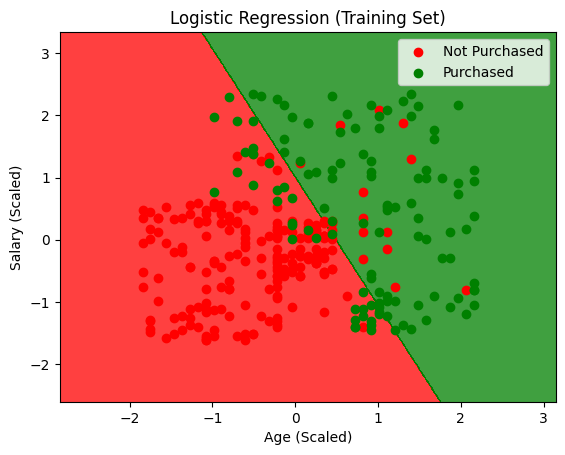

In [63]:
X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 0.01),
    np.arange(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 0.01)
)

plt.contourf(X1,X2,
    model.predict(
        np.array([X1.ravel(), X2.ravel()]).T
    ).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.scatter(
    X_set[y_set == 0, 0],
    X_set[y_set == 0, 1],
    c='red',
    label='Not Purchased'
)

plt.scatter(
    X_set[y_set == 1, 0],
    X_set[y_set == 1, 1],
    c='green',
    label='Purchased'
)

plt.title('Logistic Regression (Training Set)')
plt.xlabel('Age (Scaled)')
plt.ylabel('Salary (Scaled)')
plt.legend()
plt.show()

## Conclusion

Logistic Regression was successfully implemented to predict customer purchase behavior. Feature scaling improved model performance, and the confusion matrix validated correct classification.